# 03 — Evaluation & Model Comparison

Compares performance of base, sft, and grpo models.

## 1. Setup

In [1]:
!git clone https://github.com/Roogard/math-rl-tuning.git
%cd math-rl-tuning

# Install the package
!pip install -e ".[viz]" --quiet
!pip install bitsandbytes latex2sympy2 --quiet
!pip install math-verify

Cloning into 'math-rl-tuning'...
remote: Enumerating objects: 907, done.
remote: Counting objects: 100% (226/226), done.
remote: Compressing objects: 100% (134/134), done.
remote: Total 907 (delta 133), reused 152 (delta 67), pack-reused 681 (from 1)
Receiving objects: 100% (907/907), 4.69 MiB | 13.87 MiB/s, done.
Resolving deltas: 100% (562/562), done.
/content/math-rl-tuning
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.3/112.3 kB 12.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 5.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.9/87.9 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 39.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.8/89.8 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 531.0/531.0 kB 49.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 433.2/433.2 MB

In [2]:
from math_rl_tuning.config import load_config
from math_rl_tuning.utils import setup_hf_token, mount_google_drive

cfg = load_config()
setup_hf_token()
mount_google_drive()

Mounted at /content/drive


## 2. Configure Model Paths

In [3]:
SFT_ADAPTER_PATH = "/content/drive/MyDrive/math-rl-tuning/sft"
RL_ADAPTER_PATH = "/content/drive/MyDrive/math-rl-tuning/grpo_checkpoint_100"
NUM_SAMPLES = 100

## 3. Load Test Data

In [4]:
from math_rl_tuning.data import prepare_test_data

test_ds = prepare_test_data(cfg)
print(f"Test examples: {len(test_ds)}")
print(f"Sample problem: {test_ds[0]['problem'][:200]}...")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00005.parquet:   0%|          | 0.00/247M [00:00<?, ?B/s]

data/train-00001-of-00005.parquet:   0%|          | 0.00/247M [00:00<?, ?B/s]

data/train-00002-of-00005.parquet:   0%|          | 0.00/247M [00:00<?, ?B/s]

...

data/train-00004-of-00005.parquet:   0%|          | 0.00/247M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/166k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/859494 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/100 [00:00<?, ? examples/s]

Eval source filter active — keeping only: ['gsm8k', 'math', 'cn_k12', 'orca_math', 'synthetic_math', 'olympiads', 'aops_forum', 'amc_aime']
Test set size: 76
Test set sources: ['amc_aime', 'aops_forum', 'cn_k12', 'gsm8k', 'math', 'olympiads', 'orca_math']
Test examples: 76
Sample problem: Let  $x, y$  be real numbers such that  $1\le x^2-xy+y^2\le2$ . Show that:
a)  $\dfrac{2}{9}\le x^4+y^4\le 8$ ;
b)  $x^{2n}+y^{2n}\ge\dfrac{2}{3^n}$ , for all  $n\ge3$ .

*Laurențiu Panaitopol* and *I...


## 4. Head-to-Head Comparison (Base vs SFT vs RL)

In [5]:
from math_rl_tuning.evaluation import compare_models, save_results

# compare_models loads the base model once and swaps LoRA adapters between evaluations,
# avoiding redundant 14GB+ model reloads. Order: Base → SFT → RL (GRPO).
# This also ensures each model is evaluated on the SAME sampled test subset
# (same random_state), making accuracy numbers directly comparable.
results = compare_models(
    sft_adapter_path=SFT_ADAPTER_PATH,
    rl_adapter_path=RL_ADAPTER_PATH,
    test_dataset=test_ds,
    cfg=cfg,
    num_samples=NUM_SAMPLES,
)

# Save results to disk as JSON (summary) and CSV (per-example predictions)
save_results(results, cfg.paths.eval_output_dir)

  HEAD-TO-HEAD MODEL COMPARISON

Loading base model: Qwen/Qwen2.5-Math-7B
Loading tokenizer: Qwen/Qwen2.5-Math-7B


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

SFT Accuracy: 0.5000  (38/76)

Loading RL adapter: /content/drive/MyDrive/math-rl-tuning/grpo_checkpoint_100


/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:285: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


Evaluating RL (GRPO) on 76 examples (batch_size=16)...


Batches: 100%|██████████| 5/5 [27:29<00:00, 329.87s/it]


RL (GRPO) Accuracy: 0.3553  (27/76)
Memory cleared.

  RESULTS
Base Accuracy:      34.21%
SFT Accuracy:       50.00%  (+15.79% vs Base)
RL (GRPO) Accuracy: 35.53%  (-14.47% vs SFT)

SFT fixed 17 Base errors, regressed on 5.
RL fixed 5 SFT errors, regressed on 16.
Summary saved to: ./outputs/eval/summary.json
base_results saved to: ./outputs/eval/base_results.csv
sft_results saved to: ./outputs/eval/sft_results.csv
rl_results saved to: ./outputs/eval/rl_results.csv


## 5. Visualize Results

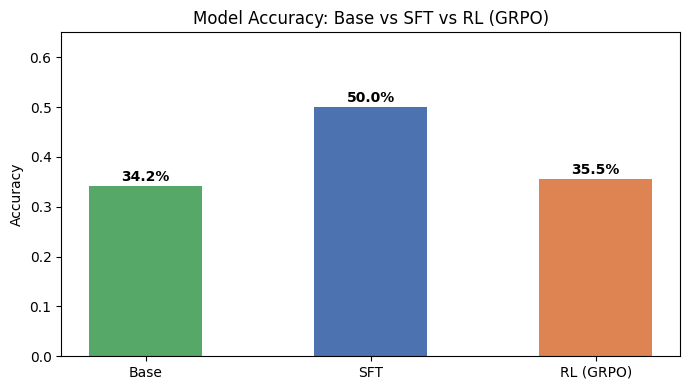

In [6]:
import matplotlib.pyplot as plt
import pandas as pd

# Bar chart: accuracy comparison across all three models
fig, ax = plt.subplots(figsize=(7, 4))

model_labels = []
accuracies = []
colors = []

if "base_accuracy" in results:
    model_labels.append("Base")
    accuracies.append(results["base_accuracy"])
    colors.append("#55A868")

model_labels += ["SFT", "RL (GRPO)"]
accuracies += [results["sft_accuracy"], results["rl_accuracy"]]
colors += ["#4C72B0", "#DD8452"]

bars = ax.bar(model_labels, accuracies, color=colors, width=0.5)
ax.set_ylabel("Accuracy")
ax.set_title("Model Accuracy: Base vs SFT vs RL (GRPO)")
ax.set_ylim(0, max(accuracies) * 1.2 + 0.05)

for bar, acc in zip(bars, accuracies):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{acc:.1%}",
        ha="center",
        fontweight="bold",
    )

plt.tight_layout()
plt.savefig("accuracy_comparison.png", dpi=150)
plt.show()

In [7]:
def show_comparison(df, col_a, col_b, label_a, label_b):
    """Print cases where model B fixed model A's errors, and vice versa."""
    gains = df[(~df[f"{col_a}_correct"]) & df[f"{col_b}_correct"]]
    regressions = df[df[f"{col_a}_correct"] & (~df[f"{col_b}_correct"])]
    print(f"{label_b} fixed {len(gains)} {label_a} errors, regressed on {len(regressions)}.")
    if not gains.empty:
        print(f"\n=== {label_b} Improvements over {label_a} ===")
        display(gains[["problem_snippet", "ground_truth"]].reset_index(drop=True))

# Base → SFT
if "base_vs_sft" in results:
    print("── Base → SFT ──────────────────────────────")
    show_comparison(results["base_vs_sft"], "Base", "SFT", "Base", "SFT")

# SFT → RL
if "sft_vs_rl" in results:
    print("\n── SFT → RL ────────────────────────────────")
    show_comparison(results["sft_vs_rl"], "SFT", "RL", "SFT", "RL")

── Base → SFT ──────────────────────────────
SFT fixed 17 Base errors, regressed on 5.

=== SFT Improvements over Base ===


,problem_snippet,ground_truth
0,"There are 2022 hamsters, some of which always ...",1011
1,what is the sum of 100 consecutive integers fr...,50
2,Elective 4-4: Coordinate System and Parametric...,"\left(\frac{3}{2}, \frac{1}{2}\right)"
3,The graph of the function $y= \sqrt{3}\cos x +...,A
4,"The numbers \( p \), \( q \), and \( pq + 1 \)...",(2p+q)(p+2q) \text{ is divisible by 4}
5,"Given the universal set $U=\{1,2,3,4,5,6,7\}$,...",A
6,Given the function $f(x)=|2x-1|$.\n(I) If the ...,4
7,The distance from the center of the circle \\(...,\text{A}
8,There are 120 crayons in a box. One third of t...,56
9,A bullet train 240 m long is running with a sp...,8



── SFT → RL ────────────────────────────────
RL fixed 5 SFT errors, regressed on 16.

=== RL Improvements over SFT ===


,problem_snippet,ground_truth
0,"Given that $a$, $b$, $c$ are all positive numb...",\frac{a}{{b+c}} + \frac{b}{{a+c}} + \frac{c}{{...
1,A and B participate in a shooting game. Accord...,\text{D}
2,Ten identical crates each of dimensions $3\mat...,190
3,If $\cos\left(\frac{\pi}{8}-\alpha\right) = \f...,\dfrac{17}{18}
4,Billy worked for 3 straight hours on his homew...,3:1


## 6. Cleanup

In [8]:
from math_rl_tuning.utils import clean_memory
clean_memory()

Memory cleared.
